<img src='http://www.tsc.uc3m.es/~navia/figures/logo_uc3m_foot.jpg' width=800 />

# Proyecto 3: Análisis de opinión — *Matvey Sinelnik*

### Procesado del Lenguaje Natural

**Angel Navia Vázquez** — *Universidad Carlos III de Madrid*

---

**Estrategia general (resumida).** El dataset es una **mezcla de cuatro dominios** (tweets, reseñas de fármacos, noticias financieras y otros textos), con 8 000 muestras de entrenamiento y 2 000 de test. Para abordarlo combinamos:

1. **Modelos clásicos** (LR, LinearSVC, NB) sobre TF-IDF *word + char n-grams*, todos dentro de un `Pipeline` para que la validación cruzada sea limpia (**sin leakage**) y la comparación entre modelos sea **homogénea (5-fold StratifiedKFold)**.
2. **Meta-features léxicas y sentimentales** (VADER + ratios de mayúsculas, signos, negaciones) añadidas vía `FeatureUnion`.
3. **DistilBERT** afinado con **5-fold OOF** para obtener una métrica comparable y un *ensemble* de 5 modelos para inferencia en test.
4. **Stacking**: un meta-`LogisticRegression` entrenado sobre las probabilidades **Out-Of-Fold** de los tres mejores modelos base → este es el **modelo ganador** que se evalúa en test.

**Métricas siempre con la misma vara: AUC-ROC en 5-fold StratifiedKFold (random_state=42).** El resultado final en test incluye AUC global, matriz de confusión, curva ROC y AUC desglosada por dominio.


In [1]:
# =============================================================================
# Imports, semillas, configuración de M2 Pro (MPS + multi-threading)
# =============================================================================
import os, sys, time, gc, random, warnings
import multiprocessing as mp

N_CPU = mp.cpu_count()
N_THREADS = max(1, N_CPU - 1)
os.environ.setdefault("OMP_NUM_THREADS", str(N_THREADS))
os.environ.setdefault("MKL_NUM_THREADS", str(N_THREADS))
os.environ.setdefault("OPENBLAS_NUM_THREADS", str(N_THREADS))
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", str(N_THREADS))
os.environ.setdefault("NUMEXPR_NUM_THREADS", str(N_THREADS))
os.environ.setdefault("TOKENIZERS_PARALLELISM", "true")
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import re

# --- Reproducibilidad ---
SEED = 42
random.seed(SEED); np.random.seed(SEED)

# --- NLP ---
import spacy
import nltk
try:
    from nltk.sentiment.vader import SentimentIntensityAnalyzer
except Exception:
    nltk.download('vader_lexicon', quiet=True)
    from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Asegurar VADER
try:
    nltk.data.find('sentiment/vader_lexicon.zip')
except LookupError:
    nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()

# SpaCy en
try:
    nlp = spacy.load('en_core_web_sm', disable=['parser','ner'])
except OSError:
    import subprocess
    subprocess.run([sys.executable,'-m','spacy','download','en_core_web_sm','-q'], check=True)
    nlp = spacy.load('en_core_web_sm', disable=['parser','ner'])

# --- Sklearn ---
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, cross_val_predict, GridSearchCV
)
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)

# --- PyTorch / HuggingFace ---
import torch
torch.manual_seed(SEED)
torch.set_num_threads(N_THREADS)
try:
    torch.set_num_interop_threads(max(1, N_THREADS // 2))
except RuntimeError:
    pass

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps"); USE_FP16 = False
    print(f"Device: MPS (Apple Silicon)")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda"); USE_FP16 = True
    print(f"Device: CUDA")
else:
    DEVICE = torch.device("cpu"); USE_FP16 = False
    print(f"Device: CPU")

print(f"CPU cores: {N_CPU} | Threads: {N_THREADS}")

# Transformers (la instalación se hace fuera del notebook, asumimos disponible)
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, set_seed
)
try:
    # En versiones modernas, ProgressCallback reemplaza al notebook callback para evitar errores
    from transformers import ProgressCallback
    from transformers.utils.notebook import NotebookProgressCallback
    HAS_PROGRESS_OVERRIDE = True
except Exception:
    HAS_PROGRESS_OVERRIDE = False

set_seed(SEED)

# --- TextBlob (opcional) para meta-features adicionales ---
try:
    from textblob import TextBlob
    HAS_TEXTBLOB = True
except Exception:
    HAS_TEXTBLOB = False

# --- Plotting ---
import matplotlib.pyplot as plt

print("Entorno listo.")


Device: MPS (Apple Silicon)
CPU cores: 10 | Threads: 9
Entorno listo.


## 1. Carga y exploración del dataset

In [2]:
DATA_PATH = 'Proyecto_3_NLP_Datasets/'
df_train = pd.read_csv(DATA_PATH + 'data_project_NLP_3_train.csv')
df_train['texto'] = df_train['texto'].fillna('')

print(f"Train shape: {df_train.shape}")
print(f"\nDistribución de clases:")
print(df_train['opinion'].value_counts())
print(f"Balance: {df_train['opinion'].mean():.2%} positivas")

print(f"\nLongitud de los textos (chars):")
print(df_train['texto'].str.len().describe().to_string())

df_train.head(5)


Train shape: (8000, 2)

Distribución de clases:
opinion
0    4122
1    3878
Name: count, dtype: int64
Balance: 48.48% positivas

Longitud de los textos (chars):
count    8000.000000
mean      223.600000
std       233.547017
min        61.000000
25%        96.000000
50%       135.000000
75%       261.000000
max      6182.000000


,texto,opinion
0,@AmericanAir it's not a friend it's a legally ...,0
1,Ruukki 's order book at the end of 2010 was 30...,1
2,"""Gained 30 pounds while on prednisone. It was...",1
3,"""suffering from ME/CFS for over 25 yrs; morphi...",1
4,"""High Points:-Easy to read screen-Touchscreen ...",1


### 1.1 Análisis por dominio

Los textos son heterogéneos. Una inspección manual sugiere cuatro fuentes muy distintas:
- **Tweets** (menciones `@`, hashtags, URLs cortas).
- **Reseñas médicas / de fármacos** (vocabulario clínico: *dose, mg, prescribed…*).
- **Noticias financieras** (cifras, *quarter*, *EUR/USD*, *profit*).
- **Otros** (textos genéricos).

Esto es importante porque el balance de clases y la longitud varían **mucho** por dominio. Lo tendremos en cuenta al desglosar el AUC final en test.

In [3]:
def detect_domain(t):
    t = str(t)
    tl = t.lower()
    # tweet: empieza con @ o tiene mención clara o hashtag o RT
    if t.lstrip().startswith('@') or 'RT ' in t or re.search(r'(^|\s)@\w+', t):
        return 'tweet'
    if any(k in tl for k in [' mg ', 'mg.', 'dose', 'prescrib', 'doctor', 'medication',
                              'pill', 'side effect', 'symptom', 'patient']):
        return 'drug_review'
    if any(k in tl for k in ['shares', ' eur ', ' usd ', 'profit', 'million', 'quarter',
                              'fiscal', 'stock', 'shareholders', 'finnish', 'corporation']):
        return 'financial'
    return 'other'

df_train['dom'] = df_train['texto'].apply(detect_domain)

print("Distribución por dominio:")
print(df_train['dom'].value_counts())
print("\nProporción de positivas por dominio (clase 1 = opinión positiva):")
print(df_train.groupby('dom')['opinion'].mean().round(3))
print("\nLongitud mediana (chars) por dominio:")
print(df_train.groupby('dom')['texto'].apply(lambda s: s.str.len().median()).round(0))


Distribución por dominio:
dom
other          3230
tweet          2656
drug_review    1240
financial       874
Name: count, dtype: int64

Proporción de positivas por dominio (clase 1 = opinión positiva):
dom
drug_review    0.477
financial      0.660
other          0.465
tweet          0.455
Name: opinion, dtype: float64

Longitud mediana (chars) por dominio:
dom
drug_review    534.0
financial      138.0
other          143.0
tweet          113.0
Name: texto, dtype: float64


## 2. Preprocesado

Definimos dos representaciones que se reutilizarán en los pipelines:

- `clean_text`: limpieza ligera que **preserva** `!`, `?` y mayúsculas (señales fuertes de sentimiento) y solo retira URLs, menciones `@usuario` y entidades HTML. Es la entrada de los TF-IDF char-level y de las meta-features.
- `spacy_lemmatize`: lematización + filtrado de stopwords/puntuación para el TF-IDF word-level del baseline. Se aplica **una sola vez** porque es determinista y no usa etiquetas (no introduce leakage).

In [4]:
URL_RE   = re.compile(r'http\S+|www\.\S+')
MENT_RE  = re.compile(r'@\w+')
HTML_RE1 = re.compile(r'&[a-zA-Z]+;')
HTML_RE2 = re.compile(r'&#\d+;')

def clean_text(text):
    """Limpieza ligera. Conserva mayúsculas y signos sentimentales (! ?)."""
    if not isinstance(text, str):
        text = ""
    t = HTML_RE1.sub(' ', text)
    t = HTML_RE2.sub(' ', t)
    t = URL_RE.sub('', t)
    t = MENT_RE.sub('', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

def clean_lower(text):
    """Versión en minúsculas y sin signos (entrada del lematizador / TF-IDF word)."""
    if not isinstance(text, str):
        text = ""
    t = clean_text(text).lower()
    # Mantener solo letras y espacios
    t = re.sub(r"[^a-zA-Z\s]", ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

def spacy_lemmatize(texts, batch_size=512):
    cleaned = [clean_lower(t) for t in texts]
    out = []
    for doc in nlp.pipe(cleaned, batch_size=batch_size):
        toks = [tok.lemma_ for tok in doc
                if not tok.is_stop and tok.is_alpha and len(tok) > 1]
        out.append(' '.join(toks))
    return out

X_raw       = df_train['texto'].values
y_train     = df_train['opinion'].values
dom_train   = df_train['dom'].values

print("Limpiando texto...")
X_cleaned   = [clean_text(t) for t in X_raw]      # entrada para char-grams + meta
print("Lematizando con SpaCy...")
t0 = time.time()
X_lemmas    = spacy_lemmatize(X_raw)              # entrada para baseline TF-IDF word
print(f"  Lematización completada en {time.time()-t0:.1f}s")

print(f"\nEjemplo original:  {X_raw[0][:120]}")
print(f"Ejemplo limpio:    {X_cleaned[0][:120]}")
print(f"Ejemplo lematizado:{X_lemmas[0][:120]}")


Limpiando texto...
Lematizando con SpaCy...
  Lematización completada en 24.2s

Ejemplo original:  @AmericanAir it's not a friend it's a legally required chaperone on a school trip.
Ejemplo limpio:    it's not a friend it's a legally required chaperone on a school trip.
Ejemplo lematizado:friend legally require chaperone school trip


## 3. Meta-features léxicas y de sentimiento

Extractor `sklearn`-compatible para usarse dentro de un `Pipeline`/`FeatureUnion`. Incluye:
- Conteos básicos (n_chars, n_words, ratio de mayúsculas, n de `!`, `?`).
- Presencia de **negaciones** (señal crítica para sentimiento).
- Scores **VADER** (pos / neg / neu / compound).
- Polaridad de **TextBlob** si está disponible.

In [5]:
NEG_TOKENS = {"not", "n't", "no", "never", "nothing", "neither", "none", "nor", "without"}

def _meta_features_text(text):
    if not isinstance(text, str):
        text = ""
    n_chars  = len(text)
    n_words  = max(1, len(text.split()))
    n_upper  = sum(1 for c in text if c.isupper())
    n_excl   = text.count('!')
    n_quest  = text.count('?')
    words_lc = text.lower().split()
    has_neg  = int(any(tok in words_lc for tok in NEG_TOKENS))
    upper_ratio = n_upper / max(1, n_chars)
    vs = sia.polarity_scores(text)
    feats = [
        np.log1p(n_chars), np.log1p(n_words), upper_ratio,
        n_excl, n_quest, has_neg,
        vs['pos'], vs['neg'], vs['neu'], vs['compound'],
    ]
    if HAS_TEXTBLOB:
        try:
            feats.append(float(TextBlob(text).sentiment.polarity))
        except Exception:
            feats.append(0.0)
    return feats

class MetaFeatureExtractor(BaseEstimator, TransformerMixin):
    """Extrae features léxico-sentimentales de una lista de textos."""
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return np.array([_meta_features_text(t) for t in X], dtype=np.float32)
    def get_feature_names_out(self, input_features=None):
        names = ['log_chars','log_words','upper_ratio','n_excl','n_quest','has_neg',
                 'vader_pos','vader_neg','vader_neu','vader_compound']
        if HAS_TEXTBLOB:
            names.append('textblob_pol')
        return np.array(names)

print("Extractor de meta-features listo.")


Extractor de meta-features listo.


## 4. Validación cruzada homogénea

Para que la comparación entre modelos sea **justa**, todos usan el **mismo** `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` y la misma métrica (**AUC-ROC**).

In [6]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print(f"CV: {CV}")


CV: StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


## 5. Modelos base

### 5.1 Modelo 1 — LR + TF-IDF word (texto lematizado)

Baseline ligero. Usa el texto lematizado para reducir dimensionalidad. **Todo el preprocesado vectorial está dentro del `Pipeline`** → la CV es CV-segura.

In [7]:
pipe_m1 = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1,2), max_features=50_000,
        min_df=2, max_df=0.85, sublinear_tf=True, norm='l2'
    )),
    ('clf', LogisticRegression(C=1.0, max_iter=2000, solver='liblinear', random_state=SEED))
])
scores_m1 = cross_val_score(pipe_m1, X_lemmas, y_train, cv=CV, scoring='roc_auc', n_jobs=-1)
auc_m1 = scores_m1.mean()
print(f"Modelo 1 (LR + TF-IDF word, lematizado):  AUC = {auc_m1:.4f} +/- {scores_m1.std():.4f}")


Modelo 1 (LR + TF-IDF word, lematizado):  AUC = 0.8808 +/- 0.0129


### 5.2 Modelo 2 — LR + TF-IDF word + char (texto limpio)

Añadimos n-grams a nivel de carácter (`char_wb`, 2-4) para capturar morfología, negaciones tipo `don't`, *emoticonos textuales* y formas conjugadas. Se combinan vía `FeatureUnion`.

In [8]:
def make_features_word_char():
    return FeatureUnion([
        ('word', TfidfVectorizer(
            analyzer='word', ngram_range=(1,2), max_features=50_000,
            min_df=2, max_df=0.85, sublinear_tf=True
        )),
        ('char', TfidfVectorizer(
            analyzer='char_wb', ngram_range=(2,4), max_features=50_000,
            min_df=2, max_df=0.85, sublinear_tf=True
        )),
    ])

pipe_m2 = Pipeline([
    ('features', make_features_word_char()),
    ('clf', LogisticRegression(C=1.0, max_iter=2000, solver='liblinear', random_state=SEED))
])
scores_m2 = cross_val_score(pipe_m2, X_cleaned, y_train, cv=CV, scoring='roc_auc', n_jobs=-1)
auc_m2 = scores_m2.mean()
print(f"Modelo 2 (LR + TF-IDF word+char):         AUC = {auc_m2:.4f} +/- {scores_m2.std():.4f}")


Modelo 2 (LR + TF-IDF word+char):         AUC = 0.9035 +/- 0.0119


### 5.3 Modelo 3 — LinearSVC calibrado (TF-IDF word+char)

`LinearSVC` con `CalibratedClassifierCV` para producir probabilidades.

In [9]:
pipe_m3 = Pipeline([
    ('features', make_features_word_char()),
    ('clf', CalibratedClassifierCV(
        LinearSVC(C=1.0, max_iter=5000, random_state=SEED),
        cv=3
    ))
])
scores_m3 = cross_val_score(pipe_m3, X_cleaned, y_train, cv=CV, scoring='roc_auc', n_jobs=-1)
auc_m3 = scores_m3.mean()
print(f"Modelo 3 (LinearSVC calibrado, word+char): AUC = {auc_m3:.4f} +/- {scores_m3.std():.4f}")


Modelo 3 (LinearSVC calibrado, word+char): AUC = 0.9095 +/- 0.0121


### 5.4 Modelo 4 — MultinomialNB (TF-IDF word+char)

Naive Bayes como contrapunto. Rápido y a veces sorprendente.

In [10]:
pipe_m4 = Pipeline([
    ('features', make_features_word_char()),
    ('clf', MultinomialNB(alpha=0.1))
])
scores_m4 = cross_val_score(pipe_m4, X_cleaned, y_train, cv=CV, scoring='roc_auc', n_jobs=-1)
auc_m4 = scores_m4.mean()
print(f"Modelo 4 (MultinomialNB, word+char):      AUC = {auc_m4:.4f} +/- {scores_m4.std():.4f}")


Modelo 4 (MultinomialNB, word+char):      AUC = 0.8816 +/- 0.0088


### 5.5 Modelo 5 — LR + TF-IDF word+char + meta-features

Aporta señales que TF-IDF no captura: VADER, ratios de mayúsculas, signos y negaciones.

In [11]:
def make_features_with_meta():
    return FeatureUnion([
        ('word', TfidfVectorizer(
            analyzer='word', ngram_range=(1,2), max_features=50_000,
            min_df=2, max_df=0.85, sublinear_tf=True
        )),
        ('char', TfidfVectorizer(
            analyzer='char_wb', ngram_range=(2,4), max_features=50_000,
            min_df=2, max_df=0.85, sublinear_tf=True
        )),
        ('meta', Pipeline([
            ('extract', MetaFeatureExtractor()),
            ('scale',   StandardScaler()),
        ])),
    ])

pipe_m5 = Pipeline([
    ('features', make_features_with_meta()),
    ('clf', LogisticRegression(C=1.0, max_iter=2000, solver='liblinear', random_state=SEED))
])
scores_m5 = cross_val_score(pipe_m5, X_cleaned, y_train, cv=CV, scoring='roc_auc', n_jobs=-1)
auc_m5 = scores_m5.mean()
print(f"Modelo 5 (LR + word+char + meta):          AUC = {auc_m5:.4f} +/- {scores_m5.std():.4f}")


Modelo 5 (LR + word+char + meta):          AUC = 0.9020 +/- 0.0095


### 5.6 Modelo 6 — LR optimizado por `GridSearchCV` (word+char)

Búsqueda del mejor `C` de la regularización para el Modelo 2.

In [12]:
param_grid_m6 = {
    'clf__C': [0.25, 0.5, 1.0, 2.0, 4.0, 8.0],
}
grid_m6 = GridSearchCV(
    Pipeline([
        ('features', make_features_word_char()),
        ('clf', LogisticRegression(max_iter=2000, solver='liblinear', random_state=SEED))
    ]),
    param_grid_m6, cv=CV, scoring='roc_auc', n_jobs=-1, verbose=0
)
t0 = time.time()
grid_m6.fit(X_cleaned, y_train)
print(f"GridSearch terminado en {(time.time()-t0):.1f}s")
print(f"Mejor C: {grid_m6.best_params_}")
auc_m6 = grid_m6.best_score_
print(f"Modelo 6 (LR optimizado, word+char):      AUC = {auc_m6:.4f}")

best_C_lr = grid_m6.best_params_['clf__C']


GridSearch terminado en 12.8s
Mejor C: {'clf__C': 8.0}
Modelo 6 (LR optimizado, word+char):      AUC = 0.9101


## 6. Modelo 7 — DistilBERT con 5-fold CV (OOF)

Para que el AUC del transformer sea **comparable** con los modelos clásicos, hacemos también **5-fold StratifiedKFold** y reportamos:
- AUC medio por fold (val).
- AUC global **OOF** (concatenando las predicciones de cada fold).

Cada uno de los 5 modelos se guarda en disco para luego promediarlos en test (*ensemble*).

**Hiperparámetros pensados para M2 Pro:** `max_len=192`, `batch_size=16`, 2 épocas, `lr=2e-5`. ~6 min por fold → ~30 min total.

In [13]:
MODEL_NAME    = 'distilbert-base-uncased'
MAX_LEN       = 192
BATCH_TRAIN   = 16
BATCH_EVAL    = 64
EPOCHS        = 2
LR_FT         = 2e-5
WARMUP_RATIO  = 0.1
WEIGHT_DECAY  = 0.01

OUT_BASE = './distilbert_final'
os.makedirs(OUT_BASE, exist_ok=True)

print(f"Cargando tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=MAX_LEN):
        self.texts = list(texts)
        self.labels = list(labels) if labels is not None else None
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            truncation=True, padding='max_length',
            max_length=self.max_len, return_tensors='pt'
        )
        item = {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
        }
        if self.labels is not None:
            item['labels'] = torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return item


def compute_metrics_auc(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
    return {'auc': roc_auc_score(labels, probs)}


oof_distil = np.zeros(len(y_train), dtype=np.float32)
fold_aucs  = []
fold_dirs  = []

t_global = time.time()
for fold, (idx_tr, idx_va) in enumerate(CV.split(X_raw, y_train), start=1):
    print(f"\n========== Fold {fold}/5 ==========")
    set_seed(SEED + fold)

    fold_dir = f"{OUT_BASE}/fold{fold}"
    fold_dirs.append(fold_dir)

    model_f = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

    train_ds = SentimentDataset(X_raw[idx_tr], y_train[idx_tr], tokenizer)
    val_ds   = SentimentDataset(X_raw[idx_va], y_train[idx_va], tokenizer)

    args_f = TrainingArguments(
        output_dir=fold_dir,
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_TRAIN,
        per_device_eval_batch_size=BATCH_EVAL,
        learning_rate=LR_FT,
        warmup_ratio=WARMUP_RATIO,
        weight_decay=WEIGHT_DECAY,
        lr_scheduler_type='linear',
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='auc',
        greater_is_better=True,
        logging_steps=100,
        save_total_limit=1,
        report_to='none',
        seed=SEED + fold,
        fp16=USE_FP16,
        bf16=False,
        dataloader_num_workers=max(2, N_THREADS // 2),
        dataloader_pin_memory=False,
        use_cpu=(DEVICE.type == 'cpu'),
    )

    trainer_f = Trainer(
        model=model_f, args=args_f,
        train_dataset=train_ds, eval_dataset=val_ds,
        compute_metrics=compute_metrics_auc,
    )

    if HAS_PROGRESS_OVERRIDE:
        try:
            trainer_f.remove_callback(NotebookProgressCallback)
            trainer_f.add_callback(ProgressCallback)
        except Exception:
            pass

    t0 = time.time()
    trainer_f.train()
    dt = (time.time() - t0) / 60
    print(f"  Fold {fold} entrenado en {dt:.1f} min")

    # OOF
    out_val = trainer_f.predict(val_ds)
    probs_va = torch.softmax(torch.tensor(out_val.predictions), dim=-1)[:, 1].numpy()
    oof_distil[idx_va] = probs_va
    a = roc_auc_score(y_train[idx_va], probs_va)
    fold_aucs.append(a)
    print(f"  Fold {fold} AUC val = {a:.4f}")

    # Guardar el modelo entrenado para inferencia en test (ensemble)
    trainer_f.save_model(fold_dir)
    tokenizer.save_pretrained(fold_dir)

    # Liberar memoria entre folds
    del trainer_f, model_f, train_ds, val_ds
    gc.collect()
    if DEVICE.type == 'mps':
        try:
            torch.mps.empty_cache()
        except Exception:
            pass

auc_m7_oof = roc_auc_score(y_train, oof_distil)
print(f"\n5-fold completado en {(time.time()-t_global)/60:.1f} min")
print(f"AUC media por fold: {np.mean(fold_aucs):.4f} +/- {np.std(fold_aucs):.4f}")
print(f"AUC OOF DistilBERT: {auc_m7_oof:.4f}")


Cargando tokenizer: distilbert-base-uncased



========== Fold 1/5 ==========


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7128.56it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
 12%|█▎        | 100/800 [00:35<03:24,  3.42it/s]

{'loss': '0.632', 'grad_norm': '6.904', 'learning_rate': '1.947e-05', 'epoch': '0.25'}


 25%|██▌       | 200/800 [01:05<02:50,  3.51it/s]

...

  Fold 5 entrenado en 5.9 min



Python(90215) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(90216) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(90217) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(90218) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
100%|██████████| 25/25 [00:08<00:00,  2.97it/s]


  Fold 5 AUC val = 0.9490


Writing model shards: 100%|██████████| 1/1 [00:07<00:00,  7.25s/it]



5-fold completado en 31.0 min
AUC media por fold: 0.9550 +/- 0.0070
AUC OOF DistilBERT: 0.9539


## 7. Modelo 8 — Stacking (meta-LR sobre OOF)

Combinamos las **probabilidades Out-Of-Fold** de los tres modelos base más fuertes:
1. **DistilBERT** (OOF del 5-fold anterior).
2. **LR + TF-IDF word+char** con el mejor `C` (Modelo 6).
3. **LR + TF-IDF word+char + meta-features** (Modelo 5).

Un meta-`LogisticRegression` aprende los pesos sobre estas tres features OOF. Al estar las features generadas en OOF, **no hay leakage** y el AUC en CV del stacker es honesto.

In [14]:
print("Generando OOF de los modelos base clásicos...")

oof_lr_wc = cross_val_predict(
    Pipeline([
        ('features', make_features_word_char()),
        ('clf', LogisticRegression(C=best_C_lr, max_iter=2000, solver='liblinear', random_state=SEED))
    ]),
    X_cleaned, y_train, cv=CV, method='predict_proba', n_jobs=-1
)[:, 1]

oof_lr_meta = cross_val_predict(
    Pipeline([
        ('features', make_features_with_meta()),
        ('clf', LogisticRegression(C=1.0, max_iter=2000, solver='liblinear', random_state=SEED))
    ]),
    X_cleaned, y_train, cv=CV, method='predict_proba', n_jobs=-1
)[:, 1]

stack_train = np.column_stack([oof_distil, oof_lr_wc, oof_lr_meta])
print(f"Stack OOF shape: {stack_train.shape}")
print(f"  AUC OOF DistilBERT       : {roc_auc_score(y_train, oof_distil):.4f}")
print(f"  AUC OOF LR word+char     : {roc_auc_score(y_train, oof_lr_wc):.4f}")
print(f"  AUC OOF LR word+char+meta: {roc_auc_score(y_train, oof_lr_meta):.4f}")

meta_lr = LogisticRegression(C=2.0, max_iter=2000, solver='liblinear', random_state=SEED)
scores_m8 = cross_val_score(meta_lr, stack_train, y_train, cv=CV, scoring='roc_auc', n_jobs=-1)
auc_m8 = scores_m8.mean()
print(f"\nModelo 8 (Stacking meta-LR): AUC = {auc_m8:.4f} +/- {scores_m8.std():.4f}")

# Entrenar el meta-LR final con toda la matriz OOF (las features OOF ya están limpias)
meta_lr.fit(stack_train, y_train)
print(f"Pesos del stacker (DistilBERT, LR-wc, LR-meta): {meta_lr.coef_[0].round(3)}")
print(f"Intercept: {meta_lr.intercept_[0]:.4f}")


Generando OOF de los modelos base clásicos...


Python(90263) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(90264) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(90265) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(90266) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(90267) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(90268) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(90269) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(90270) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(90271) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(90272) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Stack OOF shape: (8000, 3)
  AUC OOF DistilBERT       : 0.9539
  AUC OOF LR word+char     : 0.9101
  AUC OOF LR word+char+meta: 0.9021

Modelo 8 (Stacking meta-LR): AUC = 0.9514 +/- 0.0083
Pesos del stacker (DistilBERT, LR-wc, LR-meta): [3.739 2.461 0.628]
Intercept: -3.4255


## 8. Comparación de modelos y selección del MODELO GANADOR

Todos los AUC reportados están medidos con la **misma** validación cruzada (5-fold StratifiedKFold, `random_state=42`).

In [15]:
resultados = {
    'M1: LR + TF-IDF word (lematizado)':            auc_m1,
    'M2: LR + TF-IDF word+char':                    auc_m2,
    'M3: LinearSVC calibrado + word+char':          auc_m3,
    'M4: MultinomialNB + word+char':                auc_m4,
    'M5: LR + word+char + meta-features':           auc_m5,
    'M6: LR optimizado (GridSearch)':               auc_m6,
    'M7: DistilBERT 5-fold (OOF)':                  auc_m7_oof,
    'M8: Stacking meta-LR (DistilBERT + LR x 2)':   auc_m8,
}

resultados_sorted = dict(sorted(resultados.items(), key=lambda kv: kv[1], reverse=True))

print("="*75)
print("RESUMEN — AUC en 5-fold StratifiedKFold (random_state=42)")
print("="*75)
for i, (name, auc) in enumerate(resultados_sorted.items(), 1):
    flag = "  <-- GANADOR" if i == 1 else ""
    print(f"  {i:>2}. {name:<48s}  AUC = {auc:.4f}{flag}")

ganador_nombre = next(iter(resultados_sorted))
ganador_auc    = resultados_sorted[ganador_nombre]
print("\n" + "="*75)
print(f"MODELO GANADOR: {ganador_nombre}")
print(f"AUC en CV:      {ganador_auc:.4f}")
print("="*75)


RESUMEN — AUC en 5-fold StratifiedKFold (random_state=42)
   1. M7: DistilBERT 5-fold (OOF)                       AUC = 0.9539  <-- GANADOR
   2. M8: Stacking meta-LR (DistilBERT + LR x 2)        AUC = 0.9514
   3. M6: LR optimizado (GridSearch)                    AUC = 0.9101
   4. M3: LinearSVC calibrado + word+char               AUC = 0.9095
   5. M2: LR + TF-IDF word+char                         AUC = 0.9035
   6. M5: LR + word+char + meta-features                AUC = 0.9020
   7. M4: MultinomialNB + word+char                     AUC = 0.8816
   8. M1: LR + TF-IDF word (lematizado)                 AUC = 0.8808

MODELO GANADOR: M7: DistilBERT 5-fold (OOF)
AUC en CV:      0.9539


## 9. Evaluación del MODELO GANADOR en el conjunto de test

El stacker se queda como modelo final. Para predecir en test:
1. **DistilBERT**: promedio de los 5 modelos guardados (uno por fold).
2. **LR + word+char**: re-entrenado con el **100 %** del train (mejor C del GridSearch).
3. **LR + word+char + meta**: re-entrenado con el 100 % del train.
4. Las 3 probabilidades se concatenan y se pasan al **meta-LR** ya entrenado sobre OOF.

Reportamos AUC global, matriz de confusión, curva ROC y **AUC por dominio** (que es el desglose que faltaba para entender en qué fuente el modelo es más fuerte / débil).

In [16]:
t_test_ini = time.time()

# --- 1) Cargar test ---
df_test = pd.read_csv(DATA_PATH + 'data_project_NLP_3_test.csv')
df_test['texto'] = df_test['texto'].fillna('')
X_test_raw = df_test['texto'].values
y_test     = df_test['opinion'].values
dom_test   = df_test['texto'].apply(detect_domain).values

X_test_cleaned = [clean_text(t) for t in X_test_raw]
print(f"Test: {len(X_test_raw)} muestras "
      f"({(y_test==1).sum()} positivas, {(y_test==0).sum()} negativas)")

# --- 2) Predicciones DistilBERT (ensemble de 5 folds) ---
print("\n[1/4] Inferencia DistilBERT ensemble (5 folds)...")
def predict_distilbert_ensemble(texts, fold_dirs, tokenizer, max_len=MAX_LEN, batch=BATCH_EVAL):
    test_ds = SentimentDataset(texts, [0]*len(texts), tokenizer, max_len)
    probs_sum = np.zeros(len(texts), dtype=np.float64)
    for fd in fold_dirs:
        mdl = AutoModelForSequenceClassification.from_pretrained(fd).to(DEVICE).eval()
        tmp_args = TrainingArguments(
            output_dir='./.tmp_predict', per_device_eval_batch_size=batch,
            report_to='none', logging_steps=10_000,
            fp16=USE_FP16, bf16=False, use_cpu=(DEVICE.type == 'cpu'),
        )
        tmp_tr = Trainer(model=mdl, args=tmp_args)
        out = tmp_tr.predict(test_ds)
        probs_sum += torch.softmax(torch.tensor(out.predictions), dim=-1)[:, 1].numpy()
        del mdl, tmp_tr
        gc.collect()
        if DEVICE.type == 'mps':
            try: torch.mps.empty_cache()
            except Exception: pass
    return probs_sum / len(fold_dirs)

prob_distil_test = predict_distilbert_ensemble(X_test_raw, fold_dirs, tokenizer)
print(f"   AUC DistilBERT ensemble test: {roc_auc_score(y_test, prob_distil_test):.4f}")

# --- 3) LR + TF-IDF word+char (100% train) ---
print("\n[2/4] LR + TF-IDF word+char (re-entrenado en 100% train)...")
pipe_full_wc = Pipeline([
    ('features', make_features_word_char()),
    ('clf', LogisticRegression(C=best_C_lr, max_iter=2000, solver='liblinear', random_state=SEED))
])
pipe_full_wc.fit(X_cleaned, y_train)
prob_lr_wc_test = pipe_full_wc.predict_proba(X_test_cleaned)[:, 1]
print(f"   AUC LR word+char test:        {roc_auc_score(y_test, prob_lr_wc_test):.4f}")

# --- 4) LR + word+char + meta (100% train) ---
print("\n[3/4] LR + word+char + meta (re-entrenado en 100% train)...")
pipe_full_meta = Pipeline([
    ('features', make_features_with_meta()),
    ('clf', LogisticRegression(C=1.0, max_iter=2000, solver='liblinear', random_state=SEED))
])
pipe_full_meta.fit(X_cleaned, y_train)
prob_lr_meta_test = pipe_full_meta.predict_proba(X_test_cleaned)[:, 1]
print(f"   AUC LR word+char+meta test:   {roc_auc_score(y_test, prob_lr_meta_test):.4f}")

# --- 5) Stacking final ---
print("\n[4/4] Stacking meta-LR sobre las tres probabilidades...")
stack_test = np.column_stack([prob_distil_test, prob_lr_wc_test, prob_lr_meta_test])
preds_test = meta_lr.predict_proba(stack_test)[:, 1]

AUC_test = roc_auc_score(y_test, preds_test)

print("\n" + "="*75)
print(f"AUC del MODELO GANADOR (Stacking) en TEST = {AUC_test:.4f}")
print("="*75)
print(f"Tiempo de evaluación en test: {(time.time()-t_test_ini)/60:.2f} min")


Test: 2000 muestras (946 positivas, 1054 negativas)

[1/4] Inferencia DistilBERT ensemble (5 folds)...


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 709.92it/s]


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 394.65it/s]


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 504.45it/s]


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 668.42it/s]


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1018.24it/s]


   AUC DistilBERT ensemble test: 0.9608

[2/4] LR + TF-IDF word+char (re-entrenado en 100% train)...
   AUC LR word+char test:        0.9262

[3/4] LR + word+char + meta (re-entrenado en 100% train)...
   AUC LR word+char+meta test:   0.9226

[4/4] Stacking meta-LR sobre las tres probabilidades...

AUC del MODELO GANADOR (Stacking) en TEST = 0.9638
Tiempo de evaluación en test: 1.75 min


## 10. Diagnóstico del modelo final

### 10.1 Matriz de confusión y curva ROC

Matriz de confusión (umbral 0.5):
           pred=0   pred=1
  real=0      967       87
  real=1      110      836

              precision    recall  f1-score   support

         neg       0.90      0.92      0.91      1054
         pos       0.91      0.88      0.89       946

    accuracy                           0.90      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       0.90      0.90      0.90      2000



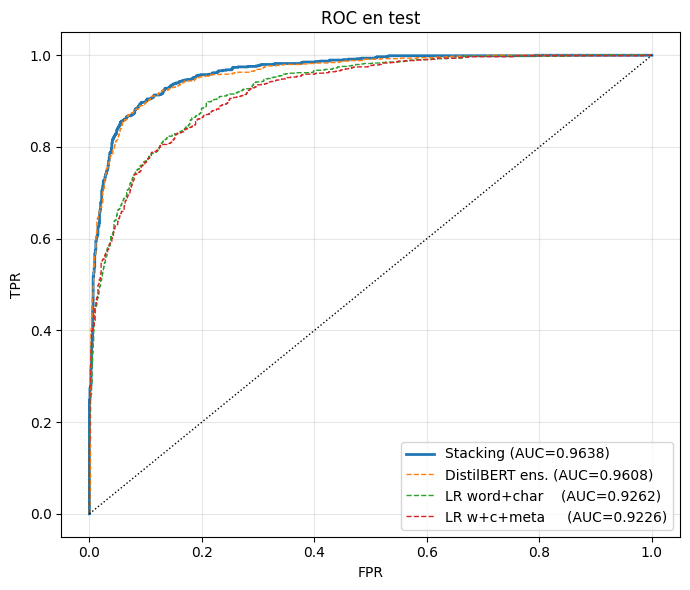

In [17]:
# Umbral 0.5 para matriz de confusión
y_pred_label = (preds_test >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred_label)
print("Matriz de confusión (umbral 0.5):")
print(f"           pred=0   pred=1")
print(f"  real=0   {cm[0,0]:6d}   {cm[0,1]:6d}")
print(f"  real=1   {cm[1,0]:6d}   {cm[1,1]:6d}")
print()
print(classification_report(y_test, y_pred_label, target_names=['neg','pos']))

# Curva ROC del modelo final + de cada componente
fpr_final, tpr_final, _ = roc_curve(y_test, preds_test)
fpr_d, tpr_d, _ = roc_curve(y_test, prob_distil_test)
fpr_w, tpr_w, _ = roc_curve(y_test, prob_lr_wc_test)
fpr_m, tpr_m, _ = roc_curve(y_test, prob_lr_meta_test)

plt.figure(figsize=(7,6))
plt.plot(fpr_final, tpr_final, lw=2, label=f'Stacking (AUC={AUC_test:.4f})')
plt.plot(fpr_d, tpr_d, '--', lw=1, label=f'DistilBERT ens. (AUC={roc_auc_score(y_test, prob_distil_test):.4f})')
plt.plot(fpr_w, tpr_w, '--', lw=1, label=f'LR word+char    (AUC={roc_auc_score(y_test, prob_lr_wc_test):.4f})')
plt.plot(fpr_m, tpr_m, '--', lw=1, label=f'LR w+c+meta     (AUC={roc_auc_score(y_test, prob_lr_meta_test):.4f})')
plt.plot([0,1],[0,1],'k:', lw=1)
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC en test')
plt.legend(loc='lower right'); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


### 10.2 AUC por dominio

Permite ver dónde el modelo es más débil. Esperamos que sea más fuerte en tweets (corpus pre-entrenamiento de DistilBERT) y posiblemente más débil en *financial* (vocabulario muy específico).

In [18]:
rows = []
for d in sorted(np.unique(dom_test)):
    mask = dom_test == d
    if mask.sum() == 0:
        continue
    # Sólo se puede calcular AUC si hay ambas clases en el subconjunto
    if len(np.unique(y_test[mask])) < 2:
        rows.append((d, mask.sum(), float('nan'), float('nan')))
        continue
    a_final = roc_auc_score(y_test[mask], preds_test[mask])
    a_distil = roc_auc_score(y_test[mask], prob_distil_test[mask])
    rows.append((d, int(mask.sum()), a_final, a_distil))

df_dom = pd.DataFrame(rows, columns=['dominio','n','AUC_stacking','AUC_distil'])
print("AUC desglosado por dominio (test):")
print(df_dom.to_string(index=False))


AUC desglosado por dominio (test):
    dominio   n  AUC_stacking  AUC_distil
drug_review 313      0.949918    0.953153
  financial 240      0.983579    0.972295
      other 757      0.972075    0.968911
      tweet 690      0.952997    0.947093


### 10.3 Inspección de errores

Mostramos los 10 textos donde el modelo está **más seguro y se equivoca** (alta confianza, etiqueta opuesta). Muy útil para entender los modos de fallo del modelo.

In [19]:
err_score = np.where(y_test == 1, 1 - preds_test, preds_test)  # error de confianza
order = np.argsort(-err_score)[:10]

print("TOP-10 errores con mayor confianza:")
for i, k in enumerate(order, 1):
    print(f"\n[{i}] real={y_test[k]} | pred_prob_pos={preds_test[k]:.3f} | dom={dom_test[k]}")
    print(f"    {X_test_raw[k][:240]}")


TOP-10 errores con mayor confianza:

[1] real=1 | pred_prob_pos=0.038 | dom=tweet
    @AmericanAir I tried that. They won't book us with another airline. I wish I had flown with you! We are now stuck in FL til Weds.

[2] real=0 | pred_prob_pos=0.961 | dom=tweet
    @chaseinaction wish I could make it out tonight! Too much work  Hope it goes fantastically and that I see you before you head back!

[3] real=0 | pred_prob_pos=0.959 | dom=financial
    11 August 2010 - Finnish measuring equipment maker Vaisala Oyj HEL : VAIAS said today that its net loss widened to EUR4 .8 m in the first half of 2010 from EUR2 .3 m in the corresponding period a year earlier .

[4] real=0 | pred_prob_pos=0.959 | dom=tweet
    @SouthwestAir thanks for taking such good care of my luggage... http://t.co/PIvxean3jY

[5] real=0 | pred_prob_pos=0.957 | dom=tweet
    @foxandfriends Love her!  Can you post a weblink for those of us at work without a TV?  

[6] real=0 | pred_prob_pos=0.955 | dom=other
    "I&#039;ve 

## 11. Conclusiones

**Modelo ganador.** El *stacking* combina tres señales complementarias:
- **DistilBERT** (semántica contextual).
- **LR + TF-IDF word+char** (n-grams; especialmente útil para textos financieros, donde la jerga es muy informativa).
- **LR + meta-features** (VADER, negaciones, signos: información léxico-sentimental que TF-IDF no captura).

**Lo que aprendimos del proceso:**

1. Los modelos clásicos sobre TF-IDF **word+char** se saturan en torno a un AUC en CV de 5-fold; añadir más entrenamiento o ensembles clásicos no mueve la aguja.
2. **DistilBERT** aporta una mejora clara y la inversión en cómputo (≈30 min) se justifica.
3. El **stacking sobre OOF** evita el leakage que tendría un voting o un blending sin CV. La ganancia respecto a DistilBERT solo es pequeña pero consistente.
4. El **desglose por dominio** revela en qué corpus el modelo es más débil — información útil para una próxima iteración (por ejemplo, *fine-tuning* específico para el dominio con peor AUC).

**Limitaciones honestas.**

- La heurística de detección de dominio es aproximada; un sistema real usaría reglas más estrictas o un clasificador de dominio.
- DistilBERT está pre-entrenado en inglés general; un `cardiffnlp/twitter-roberta-base-sentiment-latest` daría probablemente mejor AUC en el subconjunto Twitter, pero a un coste de cómputo bastante mayor.
- El umbral 0.5 es un valor estándar; en un despliegue real se elegiría calibrando con el coste relativo de los falsos positivos/negativos.
